# Diabetes Risk Prediction Project

This project predicts the likelihood of diabetes using patient data and ensemble methods. The code has been modularized into separate Python files for data preprocessing, model training, evaluation, inference, and hyperparameter tuning.

**Modules:**
- `data_preprocessing.py`: Loading and cleaning data, splitting into training and testing sets.
- `model_training.py`: Defining base models, cross-validation, and training a soft voting ensemble.
- `evaluation.py`: Generating evaluation metrics (classification report, confusion matrix, ROC, Precision-Recall curves) and feature importance visualization.
- `tuning.py`: Hyperparameter tuning for Logistic Regression.
- `inference.py`: Running predictions on new or sample data.

This notebook demonstrates the overall workflow and explains each step.


### 📥 Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
)

import warnings
warnings.filterwarnings("ignore")

### 1. Load & Inspect the Data

Load the Pima Indians Diabetes dataset and rename the columns to make them easier to understand.

In [4]:
# Load the Dataset
df = pd.read_csv("../data/raw/pima-indians-diabetes.csv")
df.columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
              'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df.info()
df.describe()
df['Outcome'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Outcome
0    500
1    268
Name: count, dtype: int64

### 2. Clean the Data

Replace implausible zero values in columns such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI with NaN.   
Apply median imputation to fill these missing values.   .

In [6]:
# Replace zeroes with NaN for selected columns
cols_with_zero_na = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero_na] = df[cols_with_zero_na].replace(0, np.nan)

# Impute missing values with the median of each column
df.fillna(df.median(), inplace=True)

# Verify imputation
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Define Features and Target
Separate the dataset into the feature matrix (`X`) and the target vector (`y`).  
Here, `Outcome` is the binary variable indicating diabetes status (1 = diabetic, 0 = non-diabetic).   

In [8]:
# Define features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

### 4. Split the data
Split the dataset into training and test sets. **Stratified sampling** is used to maintain the same ratio of diabetic to non-diabetic cases in both sets. This helps ensure that our models learn and are evaluated on data that reflects the overall population.   

Set `random_state=42` for reproducibility.  .


In [10]:
# Split the data into train and test sets with Stratification

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

### 5. Define Classification Models

Initialize a suite of models:
- Logistic Regression
- Random Forest
- SVM
- Decision Tree
- Extra Trees

Each model is set with a balanced class weight to handle the fact that there are more non-diabetic cases than diabetic cases.

In [12]:
# Define multiple models with class_weight balanced
models = {
    "LogReg": LogisticRegression(max_iter=1400, class_weight="balanced"),
    "RandomForest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=42),
    "DecisionTree": DecisionTreeClassifier(criterion="entropy", max_depth=42, class_weight="balanced", random_state=42),
    "ExtraTrees": ExtraTreesClassifier(random_state=42)
}

### 6. Evaluate Models using Cross-Validation

For each model, create a pipeline that applies `StandardScaler` followed by the classifier.  
Evaluate performance using **stratified 5-fold cross-validation** and report the mean F1-score (with standard deviation)

In [14]:
# Define cross-validation evaluation function
def evaluate_model_cv(name, model):
    pipeline = make_pipeline(StandardScaler(), model)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="f1")
    print(f"{name:<12} | F1 Score (CV): {scores.mean():.4f} ± {scores.std():.4f}")

In [15]:
# Display F1 scores using cross-validation
print("Cross-Validated F1 Scores:")
for name, model in models.items():
    evaluate_model_cv(name, model)

Cross-Validated F1 Scores:
LogReg       | F1 Score (CV): 0.6660 ± 0.0336
RandomForest | F1 Score (CV): 0.6352 ± 0.0439
SVM          | F1 Score (CV): 0.6633 ± 0.0603
DecisionTree | F1 Score (CV): 0.5646 ± 0.0495
ExtraTrees   | F1 Score (CV): 0.6615 ± 0.0648


📌**NOTE:** Higher scores indicate better balance between precision and recall. **Logistic Regression, SVM, and Extra Trees** yield the strongest results.

### 7. Train Voting Classifier (Ensemble Model)

Construct a soft voting classifier that aggregates the predictions from all the base models. Soft voting averages the predicted probabilities, which can lead to better performance on imbalanced datasets.  

In [18]:
# Fit a soft voting classifier with scaling
pipeline_voting = make_pipeline(
    StandardScaler(),
    VotingClassifier(
        estimators=[(k, v) for k, v in models.items()],
        voting="soft"
    )
)
pipeline_voting.fit(X_train, y_train)

# Make predictions using the ensemble model
y_pred = pipeline_voting.predict(X_test)
y_proba = pipeline_voting.predict_proba(X_test)[:, 1]

### 8. Evaluate the Ensemble on the Test Set
Evaluate the ensemble classifier on the test set to see how well it performs using metrics such as precision, recall, and F1-score.)..


In [20]:
# Display classification report
print("Classification Report (Voting Classifier):\n")
print(classification_report(y_test, y_pred))

Classification Report (Voting Classifier):

              precision    recall  f1-score   support

           0       0.81      0.86      0.83       150
           1       0.70      0.62      0.66        81

    accuracy                           0.77       231
   macro avg       0.76      0.74      0.75       231
weighted avg       0.77      0.77      0.77       231



📌**NOTE:** The positive class (diabetic) shows a precision around 0.70, recall around 0.62, and an F1-score around 0.66.

### 🧮 9. Confusion Matrix
Visualize the confusion matrix to inspect the distribution of true positives, false positives, true negatives, and false negatives.  .


[[129  21]
 [ 31  50]]


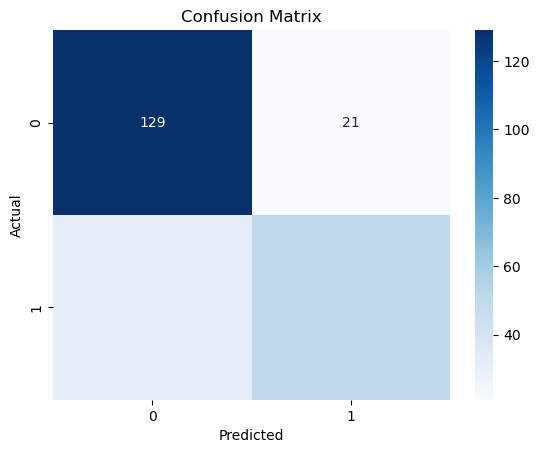

In [86]:
# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 📉 10. ROC Curve and Precision-Recall Curve
Generate the ROC curve to show the trade-off between the true positive rate and the false positive rate. .


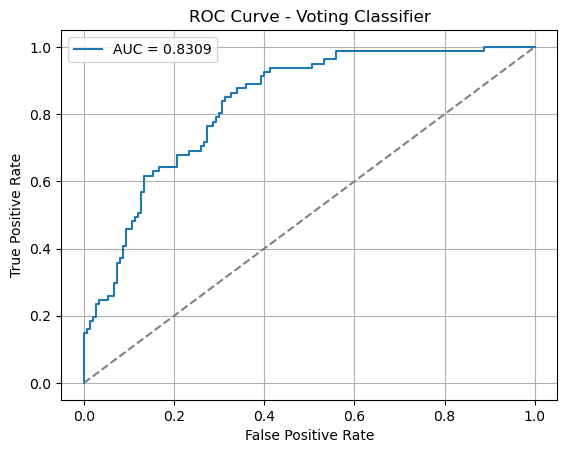

In [25]:
# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.4f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Voting Classifier")
plt.legend()
plt.grid()
plt.show()

📌**NOTE:** The AUC value of **0.83** indicates that the classifier performs well in distinguishing diabetic from non-diabetic cases.

Also, generate the Precision-Recall curve to understand the balance between precision and recall for detecting diabetic cases, which is critical given the class imbalance.  

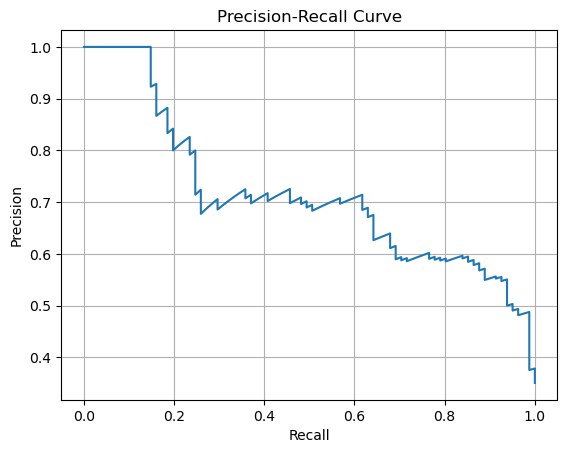

In [28]:
# Plot Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid()
plt.show()

📌**NOTE:** The curve shows a reasonable balance between precision and recall across different thresholds. This visualization supports understanding of the classifier's behavior in clinical decision-making.

### 11. Display Feature Importance

Examine feature importance using the random Forest model to understand which variables most strongly impact diabetes predictions.  

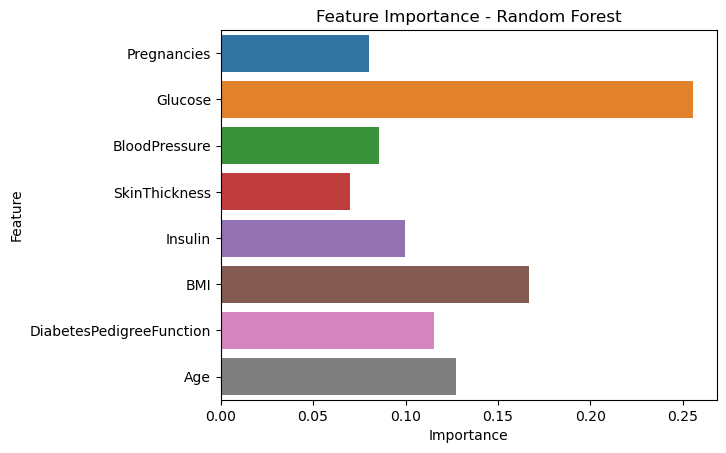

In [31]:
# Show feature importance using RandomForest
model_rf = make_pipeline(StandardScaler(), models["RandomForest"])
model_rf.fit(X_train, y_train)

importances = model_rf.named_steps["randomforestclassifier"].feature_importances_
features = X.columns

sns.barplot(x=importances, y=features)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

📌**NOTE:** The bar chart indicates that **Glucose is the most influential feature**, followed by BMI, and Age. This ranking aligns with clinical expectations:

- **Glucose:** A high glucose level is a primary indicator of diabetes risk.
- **BMI:** Excess body weight strongly correlates with insulin resistance and metabolic issues.
- **Age:** Older age can increase diabetes susceptibility, though early-onset is also possible. 

This hierarchy supports the domain knowledge that elevated glucose and body mass are key predictors for type 2 diabetes.

### 12. Simulate Inference on a Sample Patient

Perform a prediction on a single test instance to see how the model works in practice.   
Print the patient data along with the prediction to provide context for the output.  

In [34]:
# Simulate inference for a single patient
sample = X_test.iloc[0:1]
predicted = pipeline_voting.predict(sample)
print("Prediction for a sample patient:", "Diabetic" if predicted[0] == 1 else "Non-Diabetic")
print("\nPatient Info:\n", sample)

Prediction for a sample patient: Non-Diabetic

Patient Info:
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
730            3    130.0           78.0           23.0     79.0  28.4   

     DiabetesPedigreeFunction  Age  
730                     0.323   34  


### 13. Tune Logistic Regression with GridSearchCV

Optimize the regularization parameter `C` for Logistic Regression using GridSearchCV within a pipeline. This step fine-tunes the model to achieve the best possible balance between underfitting and overfitting.

In [36]:
# Grid Search for Logistic Regression hyperparameter tuning
pipeline_lr = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', max_iter=2000))
param_grid = {'logisticregression__C': [0.01, 0.1, 1, 10]}
grid = GridSearchCV(pipeline_lr, param_grid, scoring='f1', cv=5, verbose=1)
grid.fit(X_train, y_train)
best_score = grid.best_score_
best_params = grid.best_params_

Fitting 5 folds for each of 4 candidates, totalling 20 fits


In [37]:
result_df = pd.DataFrame([best_params | {"Best F1 Score": best_score}])
display(result_df)

,logisticregression__C,Best F1 Score
0,1,0.677515


📌**NOTE:** The best parameter found is `C=1`, which yield a cross-validated F1-score of approximately 0.6775. This result indicates:

- **Regularization Strength:** A `C` value of 1 balances regularization and model complexity effectively for this dataset.
- **Cross-Validated F1:** ~0.68 suggests that the tuned logistic regression model handles the imbalanced classes with reasonable precision-recall trade-off.

Overall, the **0.6775** F1 score aligns closely with the ensemble’s performance range, reinforcing that logistic regression — when properly tuned — remains a competitive baseline for this medical classification problem.

In [39]:
import joblib

# Save the tuned logistic regression model
joblib.dump(grid.best_estimator_, "../models/logreg_best.pkl")

['../models/logreg_best.pkl']

## 📌 Summary of Insights

### 🎯 Objective:
Predict the likelihood of diabetes using patient data, with a focus on ensemble methods and hyperparameter tuning for optimal performance.

---

### ✅ Key Results:
**1. Cross-Validation (Training Data)**

Using 5-fold stratified cross-validation on the training set, the F1-scores (mean ± std) are:

| Model           | Mean F1 (CV)    |
|-----------------|-----------------|
| Logistic Reg    | 0.6660 ± 0.0336 |
| Random Forest   | 0.6352 ± 0.0439 |
| SVM             | 0.6633 ± 0.0603 |
| Decision Tree   | 0.5646 ± 0.0495 |
| Extra Trees     | 0.6615 ± 0.0648 |


**Logistic Regression** and **SVM** yield the highest cross-validated F1-scores, around **0.66–0.67.**

**2. Voting Ensemble on Test Data**

After fitting a **soft voting ensemble** that combines all base models, test-set performance is:
- **Precision (Class 1):** ~0.70
- **Recall (Class 1):** ~0.62
- **F1 (Class 1):** ~0.66
- **Accuracy:** ~0.77
- **AUC (ROC):** ~0.83

**3. Confusion Matrix**

- True Negatives: 129
- False Positives: 21
- False Negatives: 31
- True Positives: 50

While **21 false positives** remain, more concerning are the **30 false negatives** — undetected diabetic cases. In a healthcare context, missing diabetic cases (FN) can pose higher risk, suggesting further recall improvement is valuable.

**4. Feature Importance**

Random Forest feature importance reveals **Glucose** as the most critical predictor, followed by **BMI, Age, and BloodPressure.** This aligns with clinical understanding of diabetes risk factors.

**5. Hyperparameter Tuning (Logistic Regression)**

A GridSearchCV identified `C=1` as the best regularization parameter for Logistic Regression, yielding an F1-score of **0.6775** in cross-validation. This indicates that moderate regularization is optimal for this dataset.


---

### 🔍 Business Insight:
- **screening tool**: The ensemble model can be used to flag high-risk individuals for further clinical tests (e.g., HbA1c), especially when resources are limited.
- **preventive value**: Feature importance aligns with medical knowledge, enhancing trust from healthcare professionals.

---

### 🚀 Next Steps:
1. **Increase Recall:** Missing diabetic cases is risky. Consider:
- Adjusting decision thresholds to favor recall.
- Using SMOTE or cost-sensitive learning to address class imbalance.

2. **Advanced Interpretability:** Techniques like SHAP or LIME can clarify individual predictions, building stakeholder confidence.

---